### Load the data set

In [63]:
#Import libraries
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


#Read the data set
df = pd.read_csv('/kaggle/input/airline-delay-cause/Airline_Delay_Cause.csv')
print(df.head())


#Create Basic subset and year index
df = df.dropna(subset=['year',
                       'month',
                       'arr_flights',
                       'airport'])
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
subset = df[['date','arr_flights','airport']]
subset.set_index('date', inplace=True)



   year  month carrier       carrier_name airport  \
0  2022      5      9E  Endeavor Air Inc.     ABE   
1  2022      5      9E  Endeavor Air Inc.     ABY   
2  2022      5      9E  Endeavor Air Inc.     ACK   
3  2022      5      9E  Endeavor Air Inc.     AEX   
4  2022      5      9E  Endeavor Air Inc.     AGS   

                                        airport_name  arr_flights  arr_del15  \
0  Allentown/Bethlehem/Easton, PA: Lehigh Valley ...        136.0        7.0   
1             Albany, GA: Southwest Georgia Regional         91.0       16.0   
2                  Nantucket, MA: Nantucket Memorial         19.0        2.0   
3           Alexandria, LA: Alexandria International         88.0       14.0   
4        Augusta, GA: Augusta Regional at Bush Field        181.0       19.0   

   carrier_ct  weather_ct  ...  security_ct  late_aircraft_ct  arr_cancelled  \
0        5.95        0.00  ...          0.0              1.00            0.0   
1        7.38        0.00  ...          

# **FLIGHT VOLUME ANALYSIS**

This section visualizes flight volume data through interactive graphics, focusing on historical trends and airport performance:

1. [**Average Annual Flight Arrivals**](#mean-of-flights-across-time): Long-term volume overviews.
2. [**Top Airport Traffic Trends**](#flight-volume-trends): Growth patterns of the highest-volume hubs.
3. [**Seasonal Flight Volume Trends**](#seasonal-flight-volume-trends): Analysis of travel peaks and troughs throughout the year.
4. [**Seasonal Flight Volume Trends (Excluding 2020)**](#seasonal-flight-volume-trends-excluding-2020): Comparison of seasonal trends during high-growth periods.
5. [**Best Airports by Flight Volume**](#top-10-airports-by-flight-volume): Ranking the busiest airports in the dataset.

## **Mean of Fligts across time**

This visualization displays the Average Annual Flight Arrivals calculated per airport-airline pair from 2003 to 2022. It allows us to observe the overall fluctuations in airline capacity and operational frequency over the last two decades.

**Conlusion from graph**
- The significant dip in the later years (likely representing the 2020 aviation industry impact), followed by the start of a recovery trend.

Text(0.5, 1.0, 'Average Annual Flight Arrivals by Airport-Airlane (2003–2022)')

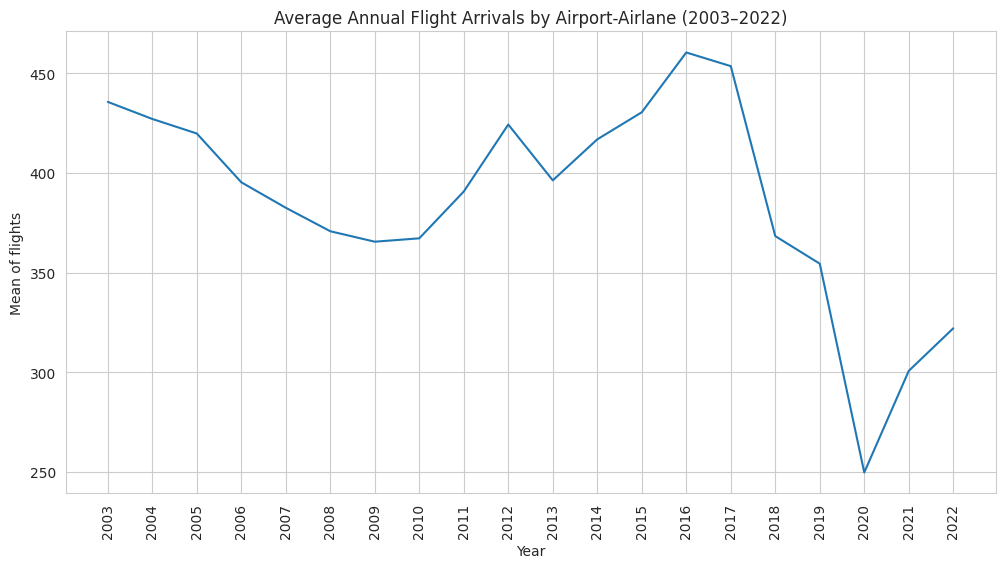

In [64]:
#Create the subset with the relevant colums
meanFlights = df[['year','arr_flights']]

#Find the mean of flights by year (Airport/Airlane)
meanFlights = meanFlights.groupby('year')['arr_flights'].mean()


#Set grid for all the next graphs
sns.set_style("whitegrid")
#Create the graph
plt.figure(figsize=(12, 6))
sns.lineplot(data=meanFlights)
plt.xticks(meanFlights.index, rotation=90)
plt.xlabel("Year")
plt.ylabel("Mean of flights")
plt.title("Average Annual Flight Arrivals by Airport-Airlane (2003–2022)")

## **Flight Volume Trends**
This visualization tracks the life time flight volume for the top 10 busiest airports (determined by total arrivals between 2003 and 2022). By isolating these high-volume hubs, we can compare how different major markets reacted to economic shifts and global events.

**Conclusion from graph**

- Dominance of Hartsfield-Jackson (ATL): The blue line representing ATL consistently maintains the highest flight volume throughout the entire period, peaking significantly higher than other hubs between 2016 and 2018.

- The 2020 "V-Shaped" Recovery: All top-tier airports experienced a simultaneous, sharp decline in 2020 due to global travel restrictions. However, the graph shows a strong upward trajectory starting in 2021, indicating a resilient recovery phase.

- Stability vs. Growth: While older hubs like O'Hare (ORD) show more stagnant or slightly declining trends over the long term, newer or expanding hubs like Denver (DEN) show a steadier climb, eventually overtaking other airports in the post-2020 era.

- Seasonal Volatility: The "jagged" nature of the lines indicates high seasonality in flight volume, with most airports showing consistent annual peaks (likely during summer and holiday periods) and troughs

Text(0, 0.5, 'Flights')

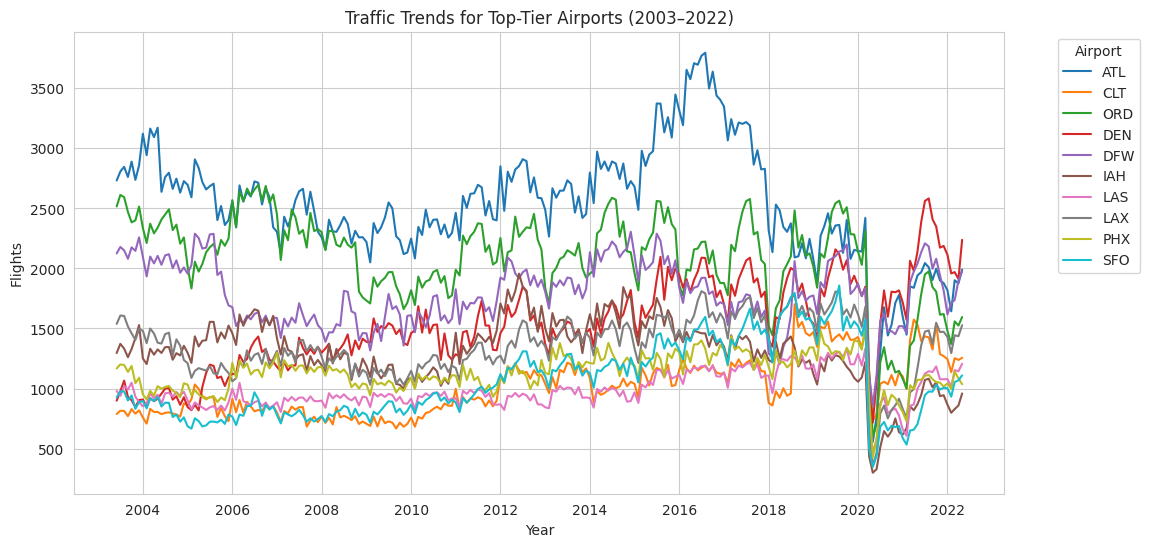

In [65]:
#Find the top 10 airports by total flights
top10 = subset.groupby('airport')['arr_flights'].sum().sort_values(ascending=False).head(10).index.tolist()

#Create the subset with only top 10 airports
subsettop5 = subset[subset['airport'].isin(top10)]

#Create the graph
plt.figure(figsize=(12, 6))
plt.title("Traffic Trends for Top-Tier Airports (2003–2022)")

sns.lineplot(data=subsettop5, x=subsettop5.index, y='arr_flights', hue='airport', errorbar=None)

plt.legend(title='Airport', bbox_to_anchor=(1.05, 1), loc='best')
plt.xlabel("Year")
plt.ylabel("Flights")


## **Seasonal Flight Volume Trends**

This visualization breaks down flight volume by month for every year in the dataset. By overlaying the years, we can identify consistent seasonal patterns and recurring "peak" travel seasons across two decades.

**Conclusions from graph**

- Summer Peak: There is a clear, consistent surge in flight volume starting in March and peaking during the summer months (July and August).

- February Dip: Across almost every year, February consistently shows the lowest flight volume, likely due to it being a shorter month and a post-holiday travel lull.

- Holiday Spikes: A secondary peak is visible in October and December, corresponding with autumn breaks and year-end holiday travel.

- The 2020 Outlier: The grey line (2020) deviates completely from historical norms, showing a catastrophic drop in April that remained well below the "floor" of previous years for the remainder of the year.

- The 2021 recover: The data reveals a sharp recovery trend starting in February 2021. By June and July, the volume successfully pivoted back to a "normal" seasonal behavior, indicating that the industry's structural patterns remained intact despite the 2020 disruption.

Text(0, 0.5, 'Flights')

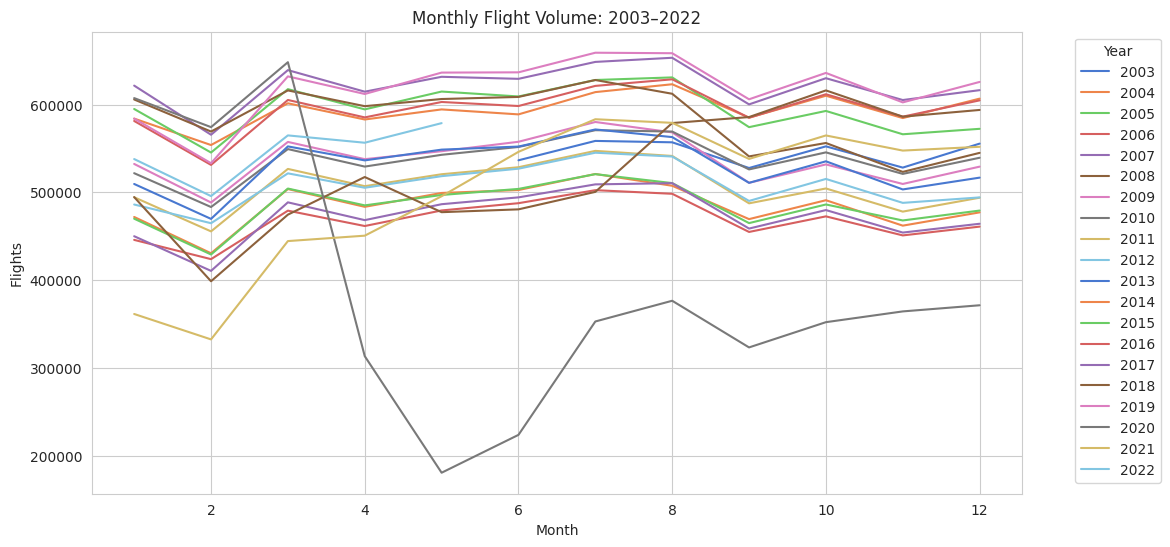

In [66]:
#Create the subset with the relevant colums
seasonal_flights = df[['year', 'month', 'arr_flights']]

#Group and sum by months-Year
flightsYear= seasonal_flights.groupby(['year', 'month'])['arr_flights'].sum().to_frame()

#Create graph
plt.figure(figsize=(12, 6))
sns.lineplot(data=flightsYear, x='month' , y='arr_flights', hue='year',palette="muted", errorbar=None)
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='best')
plt.title("Monthly Flight Volume: 2003–2022")
plt.xlabel("Month")
plt.ylabel("Flights")


Text(0, 0.5, 'Flights')

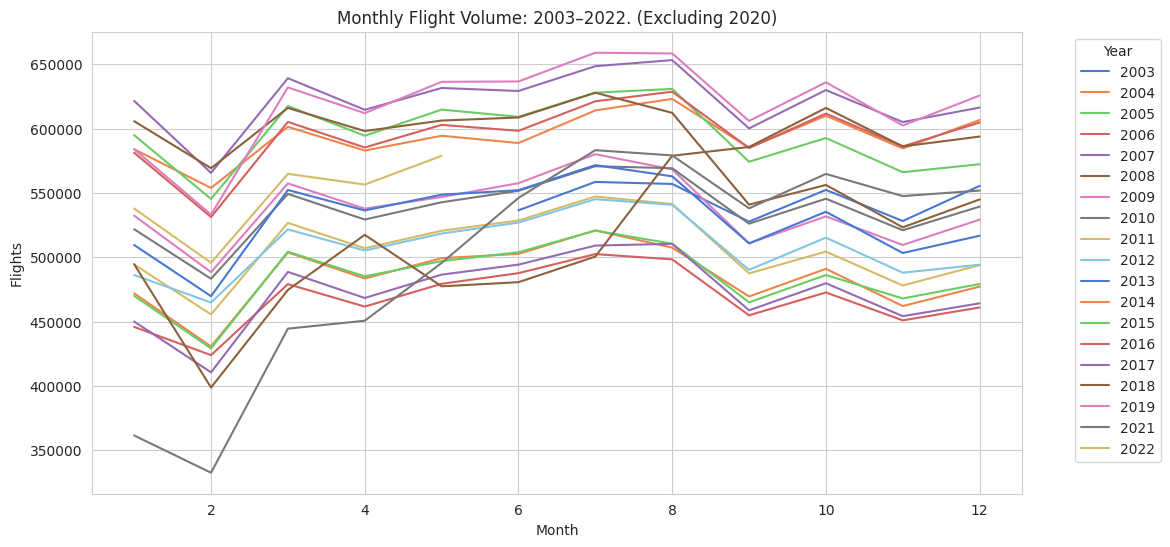

In [67]:
##Create the subset with the relevant colums
flightsYear = df.groupby(['year', 'month'])['arr_flights'].sum().reset_index()

#List the years without 2020
wo2022Flights = flightsYear[flightsYear['year']!= 2020 ]

#Create the graph
plt.figure(figsize=(12, 6))
sns.lineplot(data=wo2022Flights, x='month' , y='arr_flights', hue='year',palette="muted", errorbar=None)
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='best')
plt.title("Monthly Flight Volume: 2003–2022. (Excluding 2020)")
plt.xlabel("Month")
plt.ylabel("Flights")

Text(0, 0.5, 'Flights')

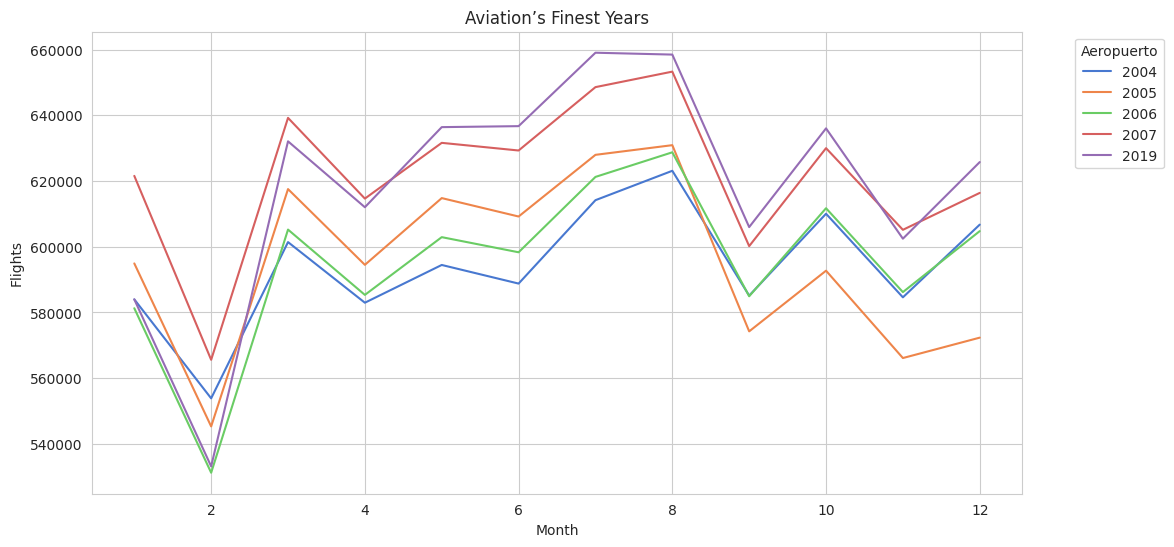

In [68]:
#Find trhe largest hightest volume airports
bestYear = flightsYear.groupby('year')['arr_flights'].sum().nlargest(5).index
BestflightsYear = flightsYear[flightsYear['year'].isin(bestYear)]

#Create the graph
plt.figure(figsize=(12, 6))
sns.lineplot(data= BestflightsYear, x='month', y='arr_flights', hue= 'year', palette="muted", errorbar=None)
plt.legend(title='Aeropuerto', bbox_to_anchor=(1.05, 1), loc='best')
plt.title("Aviation’s Finest Years")
plt.xlabel("Month")
plt.ylabel("Flights")


## **Top 10 airports by Flight Volume**

This section identifies the "heavyweights" of the aviation industry by aggregating the total number of arrived flights per airport over the entire 20-year dataset (2003–2022). By ranking these airports, we can identify which hubs serve as the primary engines for the global travel network.

**Conclusions from graph**

- Dominance of Atlanta (ATL): Hartsfield-Jackson Atlanta International Airport stands as the clear leader, significantly outperforming all other hubs with a total volume exceeding $7$ millions flights.
- Tiered Distribution: There is a noticeable "step-down" in volume after the top three airports (ATL, ORD, and DFW), suggesting a concentrated hierarchy where a few mega-hubs handle a disproportionate share of total traffic.
- Regional Powerhouses: The top 10 is largely comprised of major connecting hubs (such as DEN and CLT) and massive coastal gateways (LAX and SFO), highlighting the importance of both geographic "middle-points" and major population centers in driving flight volume.


Text(0, 0.5, 'Airport')

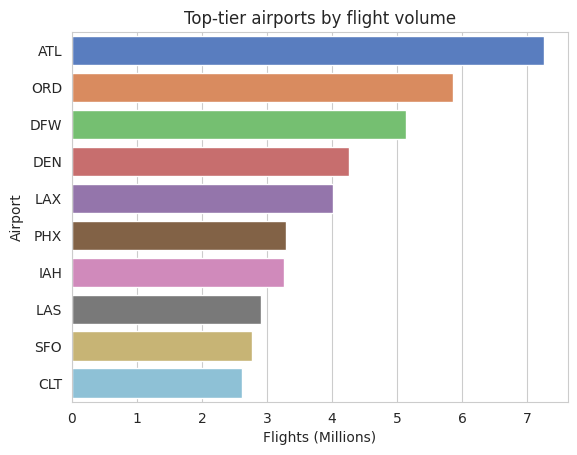

In [69]:
#List and sum flights by airlane
sumFlights = subset.groupby('airport')['arr_flights'].sum().sort_values(ascending = False).to_frame()

#Find the top 10 airlanes by life time(2003-2022) flights

top10 = sumFlights.head(10)
#Convert millions
top10 = top10/1e6

#Create graph
sns.barplot(x=top10['arr_flights'],  y= top10.index, hue=top10.index,  palette="muted")
plt.gca().ticklabel_format(axis='x', style='sci', scilimits=(0,0), useMathText=True)
plt.title("Top-tier airports by flight volume")
plt.xlabel("Flights (Millions)")
plt.ylabel("Airport")

# **DELAY CAUSES ANALYSIS**

This section investigates the primary drivers behind flight disruptions, examining carrier performance and the specific categories of operational delays:

1. [**Top 5 Airlines by Mean Annual Delay**](#top-5-airlanes-with-the-highest-avarage-anual-delay): Identifying carriers with the highest average historical wait times.
2. [**Total Delay Minutes by Cause**](#total-delay-minutes-by-cause): A breakdown of time lost to weather, security, carrier, and NAS issues.
3. [**Correlation Matrix of Delay Types**](#correlation-matrix-of-delay-types): Analyzing the statistical relationships between different delay categories.
4. [**Monthly Delay Cause Intensity**](#monthly-delay-cause-intensity): Tracking how specific delay types fluctuate throughout the calendar year.
5. [**Monthly Delay Cause Intensity (2019 - Busiest Year)**](#monthly-delay-cause-intensity-2019--busiest): A deep dive into the busiest historical year to understand delay behavior under maximum load.
6. [**Total Delay by Airport**](#total-delay-by-airport): Ranking the airports where passengers experience the highest cumulative wait times.

## **Top 5 airlanes with the highest average anual delay**

This analysis identifies the carriers that consistently recorded the highest mean arrival delays from 2003 to 2022. By tracking these "Worst 5" performers over time, we can observe how specific airlines managed operational challenges and how external factors—like the 2020 pandemic—drastically altered delay patterns

**Conclusions from graph**

- Historical Delay Leaders: Certain carriers, such as WN  and AA , consistently occupy the top of the graph, showing higher sensitivity to delays throughout the mid-2010s.

- The 2020 Operational Reset: There is a dramatic, synchronized drop in delays across all top carriers in 2020. This "bottoming out" was likely due to the massive reduction in air traffic, which cleared congestion and allowed for nearly perfect on-time performance despite the industry crisis.

- Aggressive Post-Pandemic Surge: Since 2021, there has been a sharp, steep increase in mean delays. Most of the top 5 carriers are approaching or exceeding their pre-pandemic delay levels as of 2022, suggesting that the industry is facing significant friction as it scales back up.

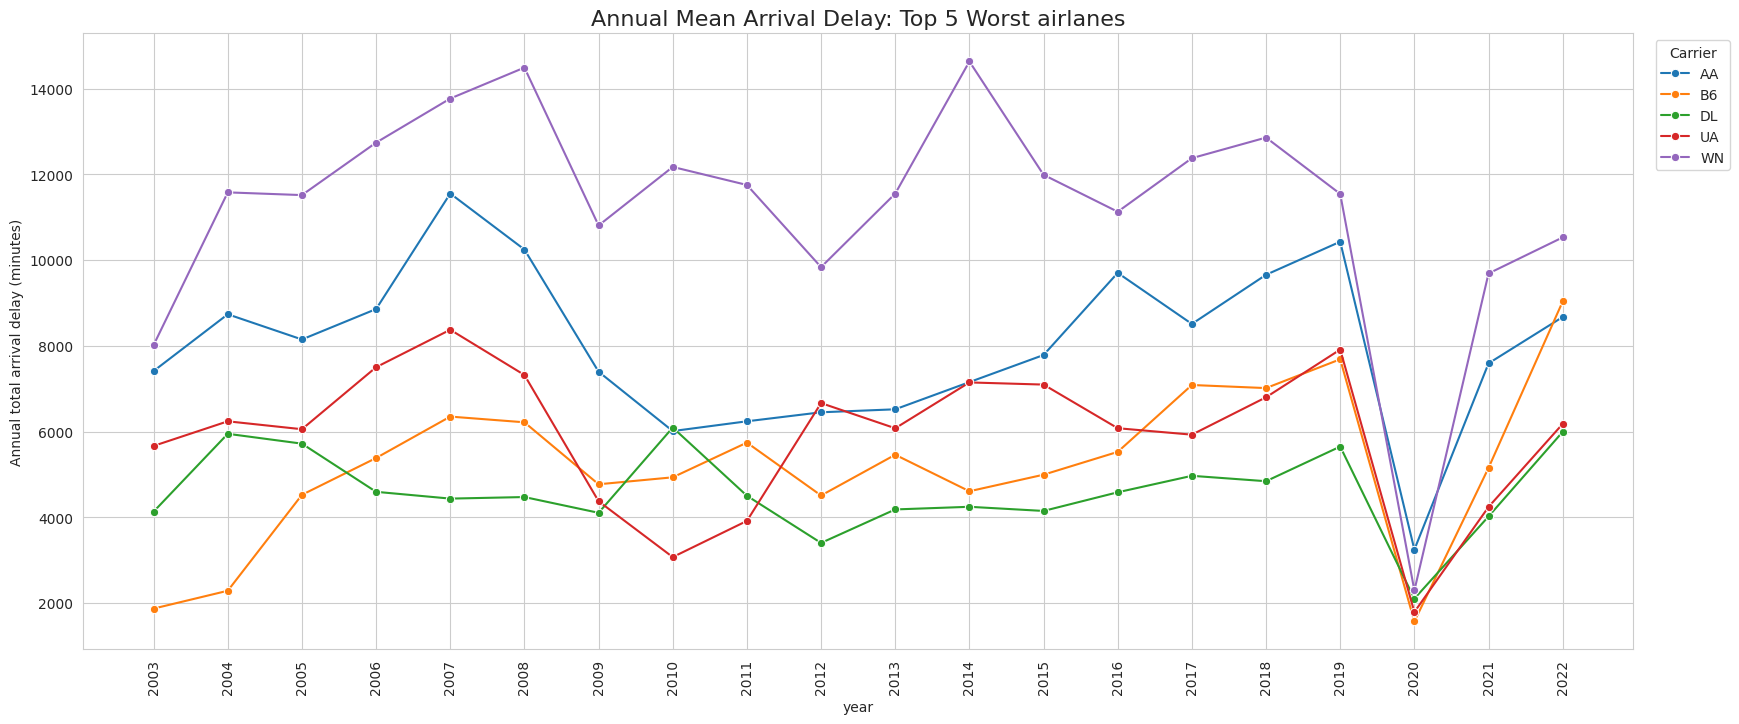

In [70]:
# Calculate the annual mean per carrier
arrBox = df.groupby(['year', 'carrier'])['arr_delay'].mean().reset_index()

# Identify the "Worst 5" carriers (highest average mean across all years)
worst_5_carriers = arrBox.groupby('carrier')['arr_delay'].mean().sort_values(ascending=False).head(5).index


# Filter the data to include only these 5 carriers
df_worst_5 = arrBox[arrBox['carrier'].isin(worst_5_carriers)]

# Create the graph
plt.figure(figsize=(20, 8))
sns.lineplot(data=df_worst_5, x='year', y='arr_delay', hue='carrier', marker='o')
plt.title('Annual Mean Arrival Delay: Top 5 Worst airlanes', fontsize=16)
plt.ylabel('Annual total arrival delay (minutes)')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Carrier')
plt.xticks(meanFlights.index, rotation=90)

plt.show()

## **Total Delay Minutes by Cause**

This analysis breaks down the total volume of flight delays by their specific category. By quantifying delays into minutes, we can distinguish between operational inefficiencies, infrastructure limitations, and uncontrollable environmental factors. This provides a clear roadmap for where the aviation industry faces its heaviest logistical bottlenecks.

**Conclusions from Graph**

- The Dominance of the "Ripple Effect": Late aircraft is the single largest contributor to total delay minutes. This highlights how a single late arrival creates a "knock-on" effect that disrupts subsequent flights throughout the day.
- Operational vs. Infrastructure Stress: The high values for Carrier and Air Traffic  suggest that internal airline management and national airspace capacity are nearly equal contributors to passenger wait times.
- The Weather: Contrary to popular belief, Weather accounts for a relatively small fraction of total delay minutes compared to technical and operational issues. This indicates that while weather is highly visible, systemic inefficiencies cause significantly more total downtime.
- Negligible Impact of Security: Security delays are statistically minimal in the context of total minutes. This suggests that TSA and airport security checkpoints, while often perceived as slow, do not contribute significantly to actual flight departure or arrival lag.

Text(0.5, 1.0, 'Total delay minutes by cause')

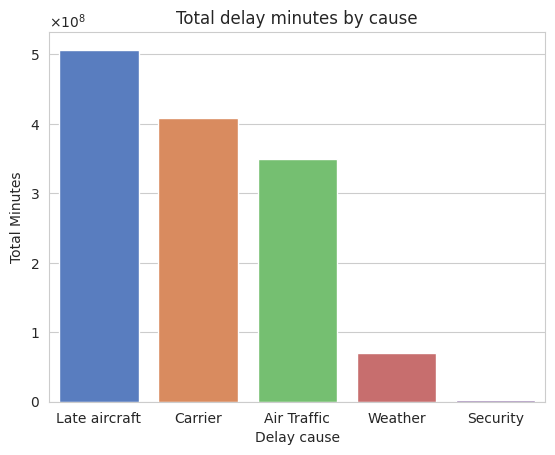

In [71]:
#
totalDelay = df.dropna(subset = ['weather_delay','nas_delay','security_delay','late_aircraft_delay'])

totalDelay = totalDelay[['carrier_delay',
                         'weather_delay',
                         'nas_delay',
                         'security_delay',
                        'late_aircraft_delay']].sum().sort_values(ascending = False).to_frame()

totalDelay = totalDelay.rename(index = { 'carrier_delay': 'Carrier',
                                        'weather_delay':'Weather',
                                        'nas_delay':'Air Traffic',
                                        'security_delay': 'Security',
                                       'late_aircraft_delay':'Late aircraft'})

totalDelay = totalDelay.rename(columns = { 0 :'TotalMinutes'})

sns.barplot(data=totalDelay, y='TotalMinutes', x=totalDelay.index, palette="muted", hue=totalDelay.index, legend=False)

plt.gca().ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)


plt.xlabel("Delay cause")
plt.ylabel("Total Minutes")

plt.title("Total delay minutes by cause")




## **Correlation Matrix of Delay Types**

This analysis explores the relationship between different delay types, specifically focusing on how Carrier delays (airline-controlled issues) and Late Aircraft delays (ripple effects) interact. By examining the correlation coefficients and the regression line, we can see how much one operational failure influences the other.

**Conclusions from Correlation and Regression**

- Strongest Statistical Link: The correlation matrix reveals that the strongest relationship in the entire dataset is between Carrier and Late Aircraft delays, with a high correlation coefficient of 0.83. This indicates that as airline-controlled delays increase, the likelihood of a late arrival causing subsequent delays rises significantly.
- The Linear Trend: The regression plot ("Linear Regression Analysis: Impact of Late Arrivals on Carrier Operations") confirms this high correlation visually. The upward-sloping trend line demonstrates a positive linear relationship; for every increase in "Late aircraft" minutes, there is a predictable and proportional increase in "Carrier" delay minutes.
- Predictability of Operational Stress:  The matrix shows that Air Traffic also has a strong link to Late Aircraft (0.73), suggesting that systemic congestion is a major driver of the "knock-on" effect.
- Security remains the outlier with the lowest correlation across all categories (ranging from 0.28 to 0.4), reinforcing that security issues act independently of general flight operations.
- Data Density and Outliers: The regression scatter plot shows a high density of data points near the origin ($0$ to $40,000$ minutes), but several significant outliers exist above $150,000$ minutes. These outliers likely represent major "meltdown" events where carrier issues and late aircraft arrivals spiraled out of control simultaneously.


<Axes: >

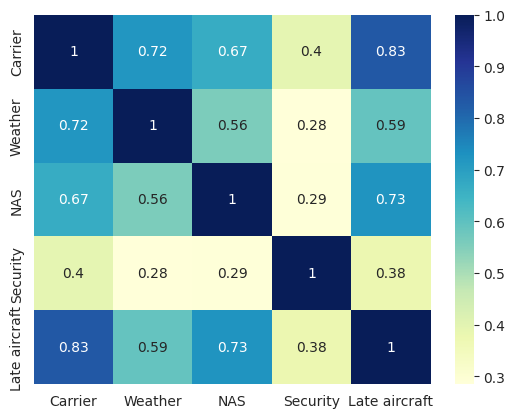

In [72]:
subCorrDelays = df[['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']]

subCorrDelays = subCorrDelays.rename(columns = { 'carrier_delay': 'Carrier',
                                        'weather_delay':'Weather',
                                        'nas_delay':'NAS',
                                        'security_delay': 'Security',
                                       'late_aircraft_delay':'Late aircraft'})

subCorr = subCorrDelays.corr()

sns.heatmap(data=subCorr,cmap="YlGnBu", annot=True)

Text(0, 0.5, 'Carrier Delay (minutes)')

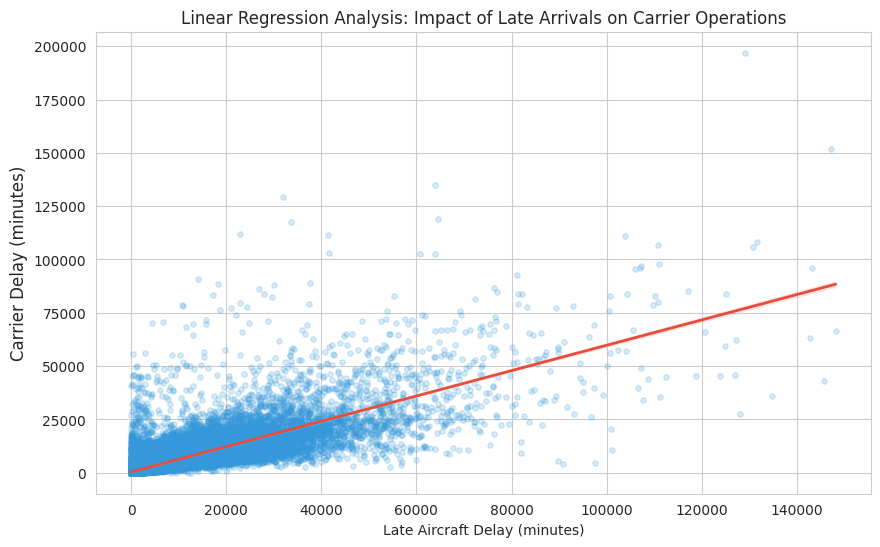

In [73]:
#Create regression graph
plt.figure(figsize=(10, 6))
sns.regplot(x=subCorrDelays['Late aircraft'], y=subCorrDelays['Carrier'],scatter_kws={'alpha': 0.2, 's': 15, 'color': '#3498db'},line_kws={'color': '#e74c3c', 'linewidth': 2})   
plt.title("Linear Regression Analysis: Impact of Late Arrivals on Carrier Operations")
plt.xlabel("Late Aircraft Delay (minutes)")
plt.ylabel("Carrier Delay (minutes)", fontsize=12)

## **Monthly Delay Cause Intensity**

This section examines the seasonality of flight disruptions. By mapping delay types by month, we can identify recurring "peak" periods—such as summer travel surges or winter weather spikes—that affect airline reliability.

**Conclusions from heatmap**

- Summer Congestion Peak: Total delay minutes typically surge in June, July, and August. This is driven by a combination of high passenger volume (increasing Carrier delays, late aircraft) and summer thunderstorms that strain the National Airspace System (NAS).
- Winter Weather Resilience: While Weather delays are expected in December and January, they often account for fewer total minutes than the Late Aircraft ripple effects caused by those same storms.
- The "Shoulder Season" Dip: Months like September and October usually show the lowest intensity, that reflects in lower delay times.

Text(120.72222222222221, 0.5, 'Year Month')

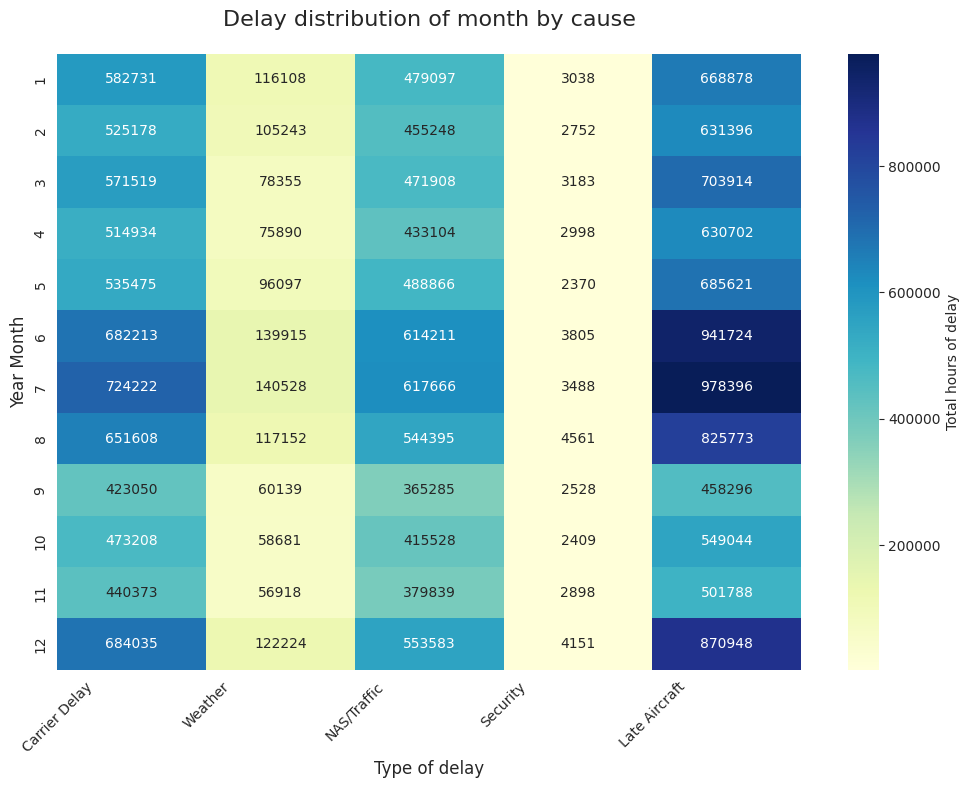

In [74]:
subDelayMonth = df[['month','carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']]

subDelayMonth = subDelayMonth.groupby('month')[['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']].sum()

subDelayMonth = subDelayMonth/60


plt.figure(figsize=(12, 8))

sns.heatmap(data=subDelayMonth, 
            annot=True, 
            fmt='.0f',
            cmap="YlGnBu",
            cbar_kws={'label': 'Total hours of delay'})

plt.xticks(ticks=[0, 1, 2, 3, 4], 
           labels=['Carrier Delay', 'Weather', 'NAS/Traffic', 'Security', 'Late Aircraft'],
           rotation=45)

plt.title('Delay distribution of month by cause', fontsize=16, pad=20)
plt.xlabel('Type of delay', fontsize=12)
plt.ylabel('Year Month', fontsize=12)

## **Monthly Delay Cause Intensity( 2019- Bussiest year)**

This section examines the seasonality of flight disruptions. By mapping delay types by month  for the year 2019, we can identify recurring "peak" periods—such as summer, corresponding to a high volume of passangers.

**Conlusion from the heatmap**

- The Summer Surge: Delays reach their maximum intensity during the summer months. This is a "perfect storm" where high passenger loads increase Carrier delays, and volatile summer weather stresses an already at-capacity Air Traffic Control system.
- December Holiday Bottleneck: A secondary spike occurs in late December. While shorter than the summer peak, the high volume of holiday travelers coupled with winter weather causes Late Aircraft delays to cascade rapidly across the network.

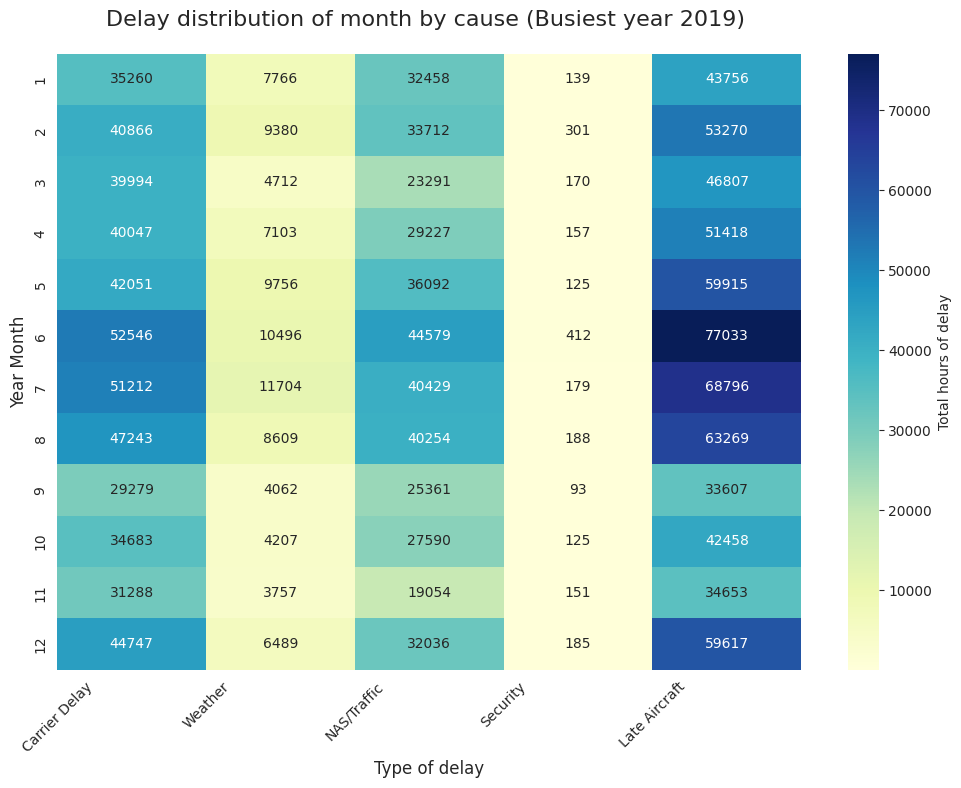

In [75]:
bestDelayCorr = df[['year','month','carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']]

bestDelayCorr = bestDelayCorr[bestDelayCorr['year'] == 2019]

bestDelayCorr = bestDelayCorr[['month','carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']]

bestDelayCorr = bestDelayCorr.groupby('month')[['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']].sum()

bestDelayCorr = bestDelayCorr/60

plt.figure(figsize=(12, 8))

sns.heatmap(data=bestDelayCorr, 
            annot=True, 
            fmt='.0f',
            cmap="YlGnBu",
            cbar_kws={'label': 'Total hours of delay'})

plt.xticks(ticks=[0, 1, 2, 3, 4], 
           labels=['Carrier Delay', 'Weather', 'NAS/Traffic', 'Security', 'Late Aircraft'],
           rotation=45)

plt.title('Delay distribution of month by cause (Busiest year 2019) ', fontsize=16, pad=20)
plt.xlabel('Type of delay', fontsize=12)
plt.ylabel('Year Month', fontsize=12)
plt.show()


## **Total delay by airport**

This horizontal analysis provides a side-by-side comparison of the nation’s busiest airports. By stacking the delay causes, we can see the "footprint" of each hub’s operational challenges, distinguishing between internal airline issues and external environmental pressures.

- Late aircraft dominance: Across almost every top airport, including Atlanta (ATL) and Chicago (ORD), the "Late Aircraft" segment (purple) represents a significant portion of the total bar. This proves that the primary driver of delays at major hubs is the arrival of late planes from previous flights, creating a cascading failure in the schedule.
- Infrastructure Stress: (ORD) and  (LAS) show the largest volume of NAS (Air Traffic) delays (green). This indicates that these specific airports are operating at their absolute capacity limits, where even minor traffic surges cause significant system-wide slowdowns.
- The Las Vegas Anomaly: Las Vegas (LAS) displays a unique profile where NAS (Air Traffic) delays (green) make up a disproportionately large percentage of its total bar compared to its Carrier delays. This indicates that the primary bottleneck in Las Vegas is the airspace or airport infrastructure rather than airline-specific operations.

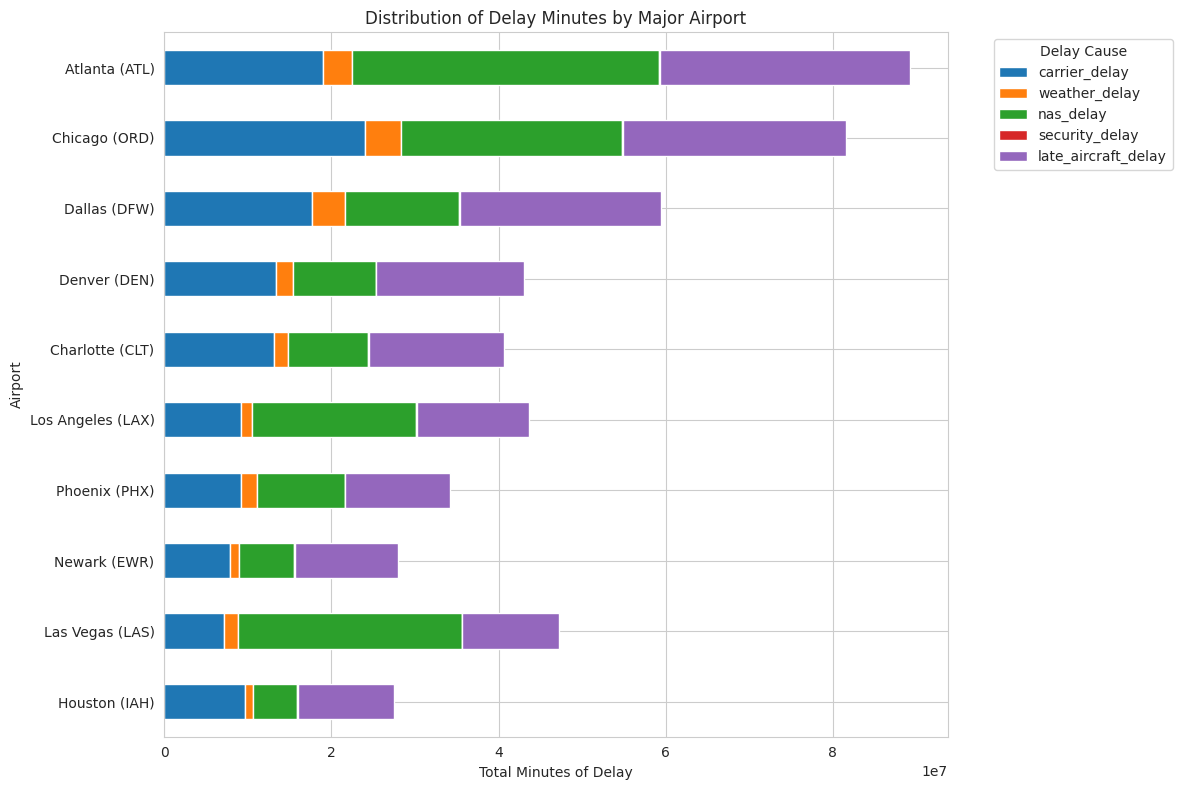

In [76]:

df.groupby('airport')[['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']].sum().sort_values('late_aircraft_delay', ascending=True).tail(10).plot(
    kind='barh', 
    stacked=True, 
    figsize=(12, 8),
    title='Distribution of Delay Minutes by Major Airport'
)

# Direct Y-axis labeling (since it's now horizontal)
plt.yticks(
    ticks=range(10), 
    labels=['Houston (IAH)', 'Las Vegas (LAS)', 'Newark (EWR)', 'Phoenix (PHX)', 'Los Angeles (LAX)', 'Charlotte (CLT)', 'Denver (DEN)', 'Dallas (DFW)', 'Chicago (ORD)', 'Atlanta (ATL)']
)

plt.xlabel('Total Minutes of Delay')
plt.ylabel('Airport')
plt.legend(title='Delay Cause', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# **CANCELATIONS ANALYSIS**

This analysis evaluates the operational reliability of major carriers by tracking the frequency of scheduled flight cancellations. Creating the avarage of cancelations iver the life time of the dataset (2003-2022)

Text(0, 0.5, 'Cancelations')

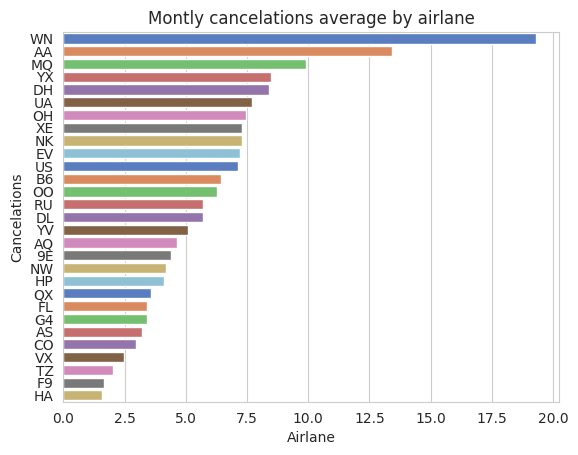

In [77]:
setCacelAir = df.dropna(subset = ['carrier', 'carrier_name', 'arr_cancelled'])

setCacelAir = df[['carrier', 'carrier_name', 'arr_cancelled']]

setCacelAir = setCacelAir.groupby("carrier")['arr_cancelled'].mean().sort_values(ascending = False).to_frame()

setCacelAir

sns.barplot(data=setCacelAir,x='arr_cancelled', y='carrier', palette="muted", hue=setCacelAir.index, legend=False)

plt.title("Montly cancelations average by airlane")
plt.xlabel("Airlane")
plt.ylabel("Cancelations")

## **Worst airlanes by cancelations**

Text(0, 0.5, 'Cancelations')

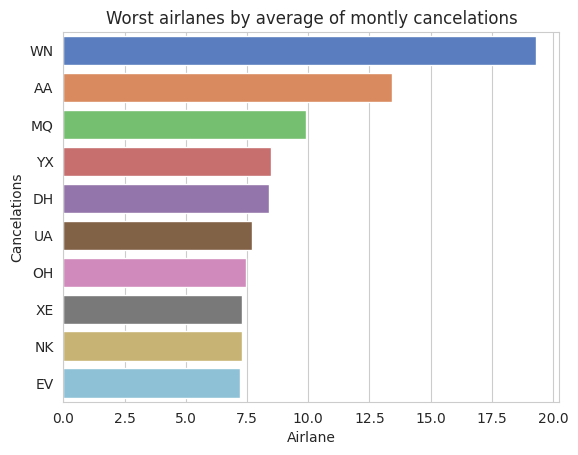

In [78]:
top10setCacelAir = setCacelAir.head(10)

sns.barplot(data=top10setCacelAir,x='arr_cancelled', y='carrier', palette="muted", hue=top10setCacelAir.index, legend=False)

plt.title("Worst airlanes by average of montly cancelations")
plt.xlabel("Airlane")
plt.ylabel("Cancelations")

## **Best airlanes by cancelations**

Text(0, 0.5, 'Cancelations')

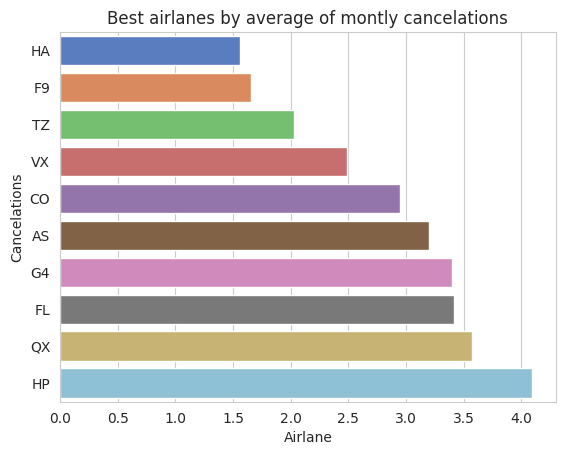

In [79]:
bottom10setCacelAir = setCacelAir.tail(10).sort_values(by="arr_cancelled", ascending=True)

sns.barplot(data=bottom10setCacelAir,x='arr_cancelled', y='carrier', palette="muted", hue=bottom10setCacelAir.index, legend=False)

plt.title("Best airlanes by average of montly cancelations")
plt.xlabel("Airlane")
plt.ylabel("Cancelations")

# **Data Distribution**

This section utilizes histograms to visualize the underlying distribution of the flight and delay data. Understanding whether our variables follow a normal (Gaussian) distribution or are skewed is a critical prerequisite for the next stage of our analysis. These insights will determine the appropriate statistical methods—such as parametric vs. non-parametric tests—required for formal Hypothesis Testing.

## **Arrival flights in log distribution**



Text(0.5, 0, 'Total Arrival Flights')

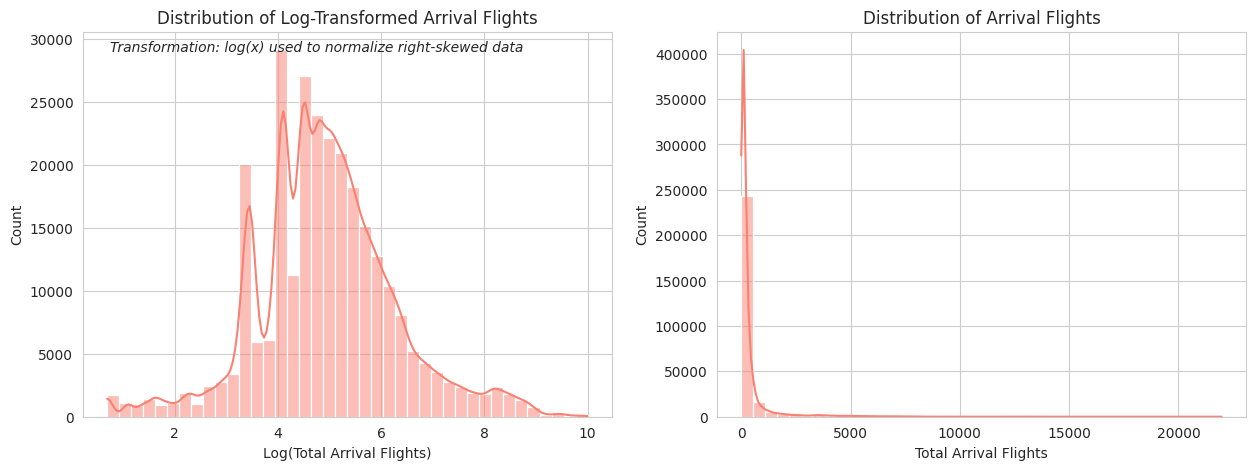

In [80]:

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# 1. Create the derived variables
df['log_arr_flights'] = np.log1p(df['arr_flights'])

# Plot 1 Log of Arrival Flights (The most "Normal" shape)
sns.histplot(excludeDF['log_arr_flights'], kde=True, bins=40, color='salmon', ax=ax[0])
ax[0].set_title('Distribution of Log-Transformed Arrival Flights')
ax[0].set_xlabel('Log(Total Arrival Flights)')

ax[0].annotate('Transformation: log(x) used to normalize right-skewed data', 
             xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, fontstyle='italic')

#Plot 2 Arrival Flights

sns.histplot(excludeDF['arr_flights'], kde=True, bins=40, color='salmon', ax=ax[1])
ax[1].set_title('Distribution of Arrival Flights')
ax[1].set_xlabel('Total Arrival Flights')



# **Delay Percentage of flights with more than a 15 minutes of delay**

Text(0.5, 0, 'Percentage of Flights Delayed (%)')

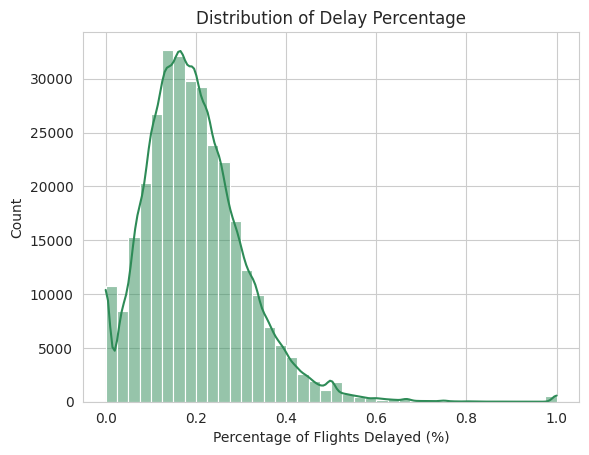

In [81]:
df['delay_percentage'] = df['arr_del15'] / df['arr_flights']

# Delay Percentage
sns.histplot(df['delay_percentage'], kde=True, bins=40, color='seagreen')
plt.title('Distribution of Delay Percentage')
plt.xlabel('Percentage of Flights Delayed (%)')


# **Data Distribution Analysis**

This section focuses on generating histograms to visualize the underlying distribution of the flight data. Understanding whether our variables follow a normal (Gaussian) distribution is a critical prerequisite for the next stage of our analysis, as it determines the validity of our statistical methods.

* **Log-Transformation Strategy:** Because arrival delays are highly right-skewed—with most flights having 0 minutes of delay and a few having extreme values—we apply a `log(x + 1)` transformation. 
* **Normalizing the Bell Curve:** This mathematical adjustment compresses the long tail of extreme delays and stretches out smaller values, successfully shifting the data into a normal distribution suitable for parametric testing.
* **Handling Zero-Delay Flights:** By using `log1p`, we preserve the 2.88% of data points representing "perfect" zero-delay operations, ensuring our sample remains representative of total airline performance.



Text(0.5, 0, 'Flight Delay (Log-Minutes)')

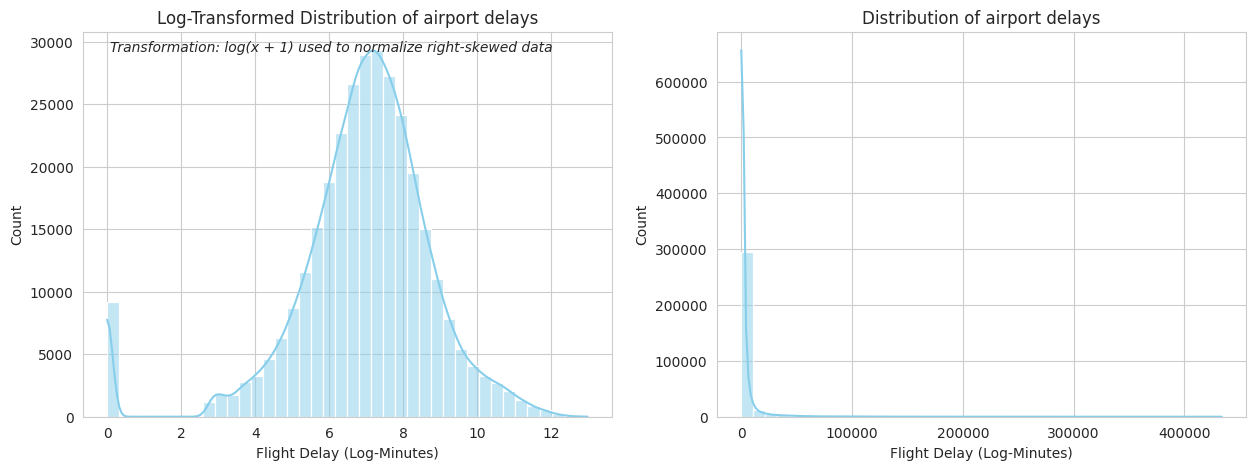

In [82]:
# Apply the transformation
df['log_arr_delay'] = np.log1p(df['arr_delay'])

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1 log arr_delay
sns.histplot(df['log_arr_delay'],kde=True, bins=40, color='skyblue', ax=ax[0])
ax[0].set_title("Log-Transformed Distribution of airport delays")
ax[0].set_xlabel("Flight Delay (Log-Minutes)")


ax[0].annotate('Transformation: log(x + 1) used to normalize right-skewed data', 
             xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, fontstyle='italic')

#Plot 2 arr_delay 

sns.histplot(df['arr_delay'],kde=True, bins=40, color='skyblue', ax=ax[1])
ax[1].set_title("Distribution of airport delays")
ax[1].set_xlabel("Flight Delay (Log-Minutes)")


# **Statistical Hypothesis Testing**

This section applies rigorous statistical methods to validate our operational observations. Using **Independent T-Tests** on our normalized data, we aim to confirm in a statistically significant way whether the differences observed in the dataset are genuine or the result of random variation.

* **The Pandemic Impact (2019 vs. 2021):** We test whether the average arrival delay shifted significantly during the industry recovery phase compared to the pre-pandemic peak of 2019.
* **Airline Operational Contrast:** By comparing major carriers like **American Airlines (AA)** and **Delta (DL)**, we determine if one airline maintains a statistically superior on-time performance over the long term.
* **Seasonal Sensitivity:** We evaluate the "Summer Surge" against the Fall "Shoulder Season" to prove if increased flight volumes and weather patterns create a statistically higher delay intensity.
* **Significance Threshold:** We utilize a **p-value of 0.1** as our decision boundary; any result below this threshold allows us to reject the null hypothesis and confirm a meaningful statistical difference.

In [83]:

# 1. Preparation: Log-transform the delay to ensure normality
df_test = df.dropna(subset=['arr_delay']).copy()
df_test['log_arr_delay'] = np.log1p(df_test['arr_delay'])

def run_ttest(group1, group2, name):
    t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)
    print(f"--- {name} ---")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_val:.4e}")
    if p_val < 0.1:
        print("Result: Statistically Significant (Reject H0)")
    else:
        print("Result: Not Significant (Fail to reject H0)")
    print("\n")

# --- TEST 1: 2019 vs 2021 ---
g1_2019 = df_test[df_test['year'] == 2019]['log_arr_delay']
g2_2021 = df_test[df_test['year'] == 2021]['log_arr_delay']
run_ttest(g1_2019, g2_2021, "2019 vs 2021 Delays")

# --- TEST 2: American Airlines (AA) vs Delta (DL) ---
g_aa = df_test[df_test['carrier'] == 'AA']['log_arr_delay']
g_dl = df_test[df_test['carrier'] == 'DL']['log_arr_delay']
run_ttest(g_aa, g_dl, "American (AA) vs Delta (DL)")

# --- TEST 3: Summer vs Fall ---
summer_months = [6, 7, 8]
fall_months = [9, 10, 11]
g_summer = df_test[df_test['month'].isin(summer_months)]['log_arr_delay']
g_fall = df_test[df_test['month'].isin(fall_months)]['log_arr_delay']
run_ttest(g_summer, g_fall, "Summer vs Fall Seasonality")

--- 2019 vs 2021 Delays ---
T-statistic: 20.7903
P-value: 1.6731e-95
Result: Statistically Significant (Reject H0)


--- American (AA) vs Delta (DL) ---
T-statistic: 50.2008
P-value: 0.0000e+00
Result: Statistically Significant (Reject H0)


--- Summer vs Fall Seasonality ---
T-statistic: 62.4020
P-value: 0.0000e+00
Result: Statistically Significant (Reject H0)




# **Hypotesis testing analysis**

## *Comparative between year before and after pandemic arrival delay*

Hypothesis: There is a statistical difference in arrival delays between the pre-pandemic year (2019) and the recovery phase (2021)

- **$ H_0 $ (Null Hypothesis)**: There is no significant difference in the average arrival delay between 2019 and 2021.
- **$ H_1 $ (Alternative Hypothesis)**: There is a statistically significant difference in the average arrival delay between 2019 and 2021.

### **Conclusion from T-Test**

Since the *p-value* is less than the significance level ( $ \alpha = 0.1 $), we reject the null hypothesis. There is sufficient evidence to conclude that a statistically significant difference exists between the average arrival delays of 2019 and 2021. This suggests that the observed variations in delay times are likely due to underlying factors related to the pandemic recovery rather than random chance.

***


 ## *Comparative between American Airlines (AA) vs Delta (DL) arrival delay*

Hypothesis: There is a statistical difference in arrival delays between the airlanes American Airlines (AA) vs Delta (DL) arrival delay

- **$ H_0 $ (Null Hypothesis)**: There is no significant difference in the average arrival in the airlanes American Airlines (AA) vs Delta (DL) arrival delay.
- **$ H_1 $ (Alternative Hypothesis)**: There is a statistically significant difference in the average arrival delay between the airlanes American Airlines (AA) vs Delta (DL) arrival delay.

### **Conclusion from T-Test**

Since the *p-value* is less than the significance level ( $ \alpha = 0.1 $), we reject the null hypothesis. There is sufficient evidence to conclude that a statistically significant difference exists between the average arrival delays of the airlanes American Airlines (AA) vs Delta (DL) arrival delay. This suggests that the observed variations in delay times are likely due to specific charactericts from each airlane rather than random.

***

## *Comparative Summer vs Fall Seasonality arrival delay*

Hypothesis: There is a statistical difference in arrival delays between the Summer seasson and Fall season.

- **$ H_0 $ (Null Hypothesis)**: There is no significant difference in the average arrival in the seasons Summer and Fall.
- **$ H_1 $ (Alternative Hypothesis)**: There is a statistically significant difference in the average arrival delay between in the seasons Summer and Fall.

### **Conclusion from T-Test**

Since the *p-value* is less than the significance level ( $ \alpha = 0.1 $), we reject the null hypothesis. There is sufficient evidence to conclude that a statistically significant difference exists between the average arrival delays of the two seasons Summer and Fall. This suggests that the observed variations in delay times are likely due to specific charactericts from each season rather than random.